In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau




In [13]:
# ==========================================
# 1. SETTINGS
# ==========================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

In [14]:
# ==========================================
# 2. DATA GENERATORS
# ==========================================

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [15]:

# ==========================================
# 3. LOAD CIFAKE TRAIN DATA
# ==========================================

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)


Found 80000 images belonging to 2 classes.


In [16]:

# ==========================================
# 4. VALIDATION DATA
# ==========================================

validation_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)


Found 20000 images belonging to 2 classes.


In [17]:

# ==========================================
# 5. CIFAKE TEST DATA
# ==========================================

test_data = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


print("\nClass indices:")
print(train_data.class_indices)


Found 20000 images belonging to 2 classes.

Class indices:
{'AI': 0, 'REAL': 1}


In [18]:

# ==========================================
# 6. MOBILE NET V2
# ==========================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [19]:

# ==========================================
# 7. CREATE MODEL
# ==========================================

model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


In [20]:
# ==========================================
# 8. COMPILE
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [21]:

# ==========================================
# 9. CALLBACKS
# ==========================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)


In [22]:


# ==========================================
# 10. TRAIN
# ==========================================

history = model.fit(

    train_data,

    validation_data=validation_data,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3311s 1s/step - accuracy: 0.8213 - loss: 0.4032 - val_accuracy: 0.8810 - val_loss: 0.2844 - learning_rate: 1.0000e-04
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3352s 1s/step - accuracy: 0.8610 - loss: 0.3255 - val_accuracy: 0.8935 - val_loss: 0.2596 - learning_rate: 1.0000e-04
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3270s 1s/step - accuracy: 0.8687 - loss: 0.3056 - val_accuracy: 0.8954 - val_loss: 0.2517 - learning_rate: 1.0000e-04
Epoch 4/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2931s 1s/step - accuracy: 0.8750 - loss: 0.2934 - val_accuracy: 0.8998 - val_loss: 0.2407 - learning_rate: 1.0000e-04
Epoch 5/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3252s 1s/step - accuracy: 0.8784 - loss: 0.2861 - val_accuracy: 0.9031 - val_loss: 0.2371 - learning_rate: 1.0000e-04
Epoch 6/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 55950s 22s/step - accuracy: 0.8848 - loss: 0.2743 - val_accuracy: 0.9043 - val_loss: 0.2320 - learning_rate: 1.0000e-04
Epoch 7/15
2500/2500 ━━━━━━━━━━━━━━━━━

In [23]:
# ==========================================
# 11. TEST
# ==========================================

test_loss, test_accuracy = model.evaluate(
    test_data
)

print("\n==============================")
print("CIFAKE TEST RESULTS")
print("==============================")

print("Test Loss:", test_loss)

print(
    "Test Accuracy:",
    test_accuracy * 100,
    "%"
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 514s 823ms/step - accuracy: 0.9105 - loss: 0.2248

CIFAKE TEST RESULTS
Test Loss: 0.2248128205537796
Test Accuracy: 91.04999899864197 %


In [24]:
# ==========================================
# 12. SAVE MODEL
# ==========================================

model.save("cifake_mobilenetv2.keras")

print("\nModel saved successfully!")



Model saved successfully!


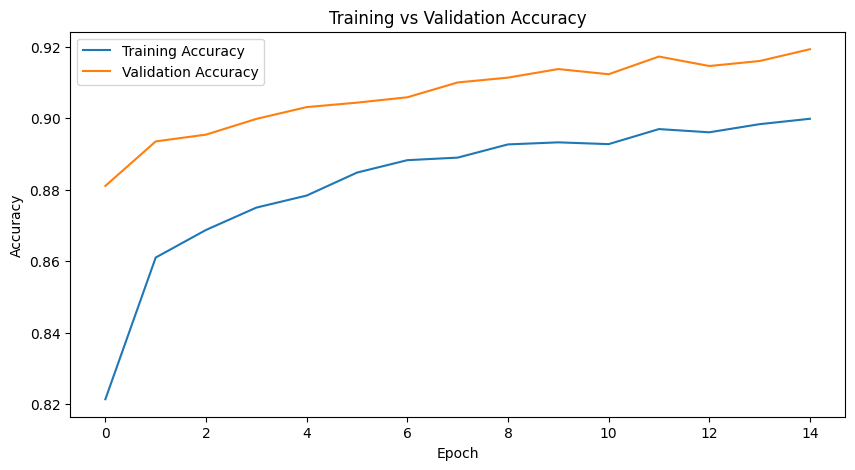

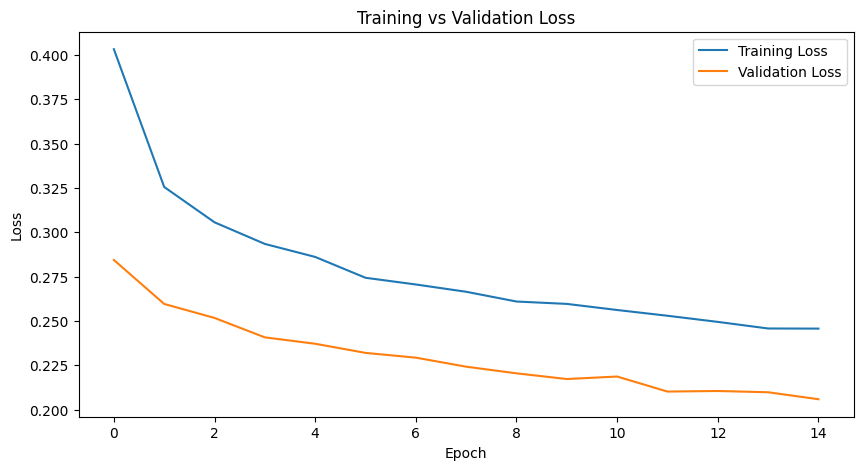

In [25]:

# ==========================================
# 13. PLOT
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()